# Stress 02 — Time Structure: Breaks, Bad Seasonality & Drifting Effectiveness

Notebook 02 of the **stress series**: the model meets worlds whose *time
structure* lies outside its hypothesis space, and we measure — against known
ground truth — where the missing structure ends up. The series thesis
([stress_00](stress_00_the_rosy_picture.ipynb)) is that **green diagnostics do
not mean correct attribution**; this notebook shows the time-structure version
of that failure, and the pivots that actually fix it.

Three acts, one mechanic. In every act the baseline does something the model's
default spec (linear trend + order-2 Fourier seasonality + constant betas)
cannot represent, and the un-representable structure has to land *somewhere*.
It lands on media **exactly when spend correlates with the unmodeled
structure**:

| act | world | the correlation that hurts | pivot |
|---|---|---|---|
| 1 | `trend_break` — level shock + recovery slope mid-series | the brand **ramps TV/Display 60% at the break** | piecewise/spline trend; event controls |
| 2 | `seasonality_misspec` — growing amplitude + sharp holiday spikes | **Social concentrates 3× in Q4**, right on the spikes | holiday dummy as a *control* (not more Fourier) |
| 3 | `time_varying_beta` — TV fatigues, Search jumps at a break | nothing in spend at all — the drift is in the *response* | split-window refits (the diagnostic IS the pivot) |

`trend_break` and `seasonality_misspec` are **new scenarios**, added to
`tests/synth/dgp.py` for this notebook — so before trusting them we validate
their internals (exact truth reconstruction, noise level), and where the
measured failure differs from the *designed* failure we say so. Each act runs:
world → naive fit → truth gap → which diagnostics fire vs. stay green → pivot
refit(s) → measured improvement → takeaway.

> Fits use the series' fast config (numpyro, 300 draws × 2 chains, parametric
> adstock). The original authoring probed every headline number across seeds
> 0–2 and across the pymc/numpyro samplers at 300–500 draws; after the trend
> defaults changed (see Act 1) the fits were re-probed at these settings and
> every directional assert below re-verifies the story live.
>
> **A note on history:** this notebook had consequences. Its first run showed
> the then-default trend priors (`growth_prior_sigma=0.1`,
> `changepoint_prior_scale=0.05`) were too stiff to use the trend the model
> *could* represent — and the framework defaults were changed to 0.5/0.5 as a
> result. The text below tells the current story, with the old defaults kept
> as explicit, labeled comparisons.

In [1]:
import sys, pathlib, warnings, logging, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # repo root (run from nbs/)

import contextlib, os
@contextlib.contextmanager
def quiet():
    "Hide sampler progress bars / chatter; our own prints stay visible."
    with open(os.devnull, "w") as _dn, contextlib.redirect_stdout(_dn), \
            contextlib.redirect_stderr(_dn):
        yield

from tests.synth import dgp  # the violation worlds (ground truth known)

plt.rcParams.update({
    "figure.figsize": (10, 4), "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 110,
})
INK, ACCENT, SKY, BERRY, LEAF, AMBER, MUTED = (
    "#2b2118", "#b5651d", "#3b6ea5", "#a63a50", "#3f7d5e", "#d98a2b", "#8a8079")
PAL = {"TV": ACCENT, "Search": SKY, "Social": BERRY, "Display": LEAF}

In [2]:
from dataclasses import replace
from mmm_framework.config import InferenceMethod, ModelConfig, SeasonalityConfig
from mmm_framework.model import BayesianMMM, TrendConfig, TrendType

# Importing pymc installs its own log handlers -> re-quiet and stop propagation.
for _n in ("pymc", "pymc.sampling", "pymc.stats.convergence",
           "numpyro", "jax", "arviz", "pytensor"):
    _lg = logging.getLogger(_n); _lg.setLevel(logging.ERROR); _lg.propagate = False

DRAWS, CHAINS = 300, 2
G, TIMINGS = {}, {}  # fitted models / wall-clock, keyed by label

def fit_grade(label, sc, trend=None, yearly=2, truth=None):
    "Fit BayesianMMM on a scenario; grade per-channel totals against truth."
    truth = sc.true_contribution if truth is None else truth
    cfg = ModelConfig(
        inference_method=InferenceMethod.BAYESIAN_NUMPYRO,
        n_chains=CHAINS, n_draws=DRAWS, n_tune=DRAWS,
        use_parametric_adstock=True, optim_seed=0,
        seasonality=SeasonalityConfig(yearly=yearly),
    )
    mmm = BayesianMMM(sc.panel(), cfg, trend or TrendConfig(type=TrendType.LINEAR))
    t0 = time.perf_counter()
    with quiet():
        res = mmm.fit(random_seed=0)
        contrib = mmm.compute_counterfactual_contributions(
            compute_uncertainty=True, hdi_prob=0.9, random_seed=0)
    TIMINGS[label] = round(time.perf_counter() - t0, 1)
    rows = []
    for c in sc.channels:
        tr, e = float(truth[c]), float(contrib.total_contributions[c])
        lo = float(contrib.contribution_hdi_low[c])
        hi = float(contrib.contribution_hdi_high[c])
        rows.append(dict(channel=c, true=tr, est=e, err=(e - tr) / abs(tr),
                         lo=lo, hi=hi, covered=bool(lo <= tr <= hi)))
    tab = pd.DataFrame(rows).set_index("channel")
    G[label] = dict(mmm=mmm, res=res, contrib=contrib, tab=tab,
                    med=float(tab["err"].abs().median()))
    print(f"[{label}]  {TIMINGS[label]:.0f}s   r-hat={res.diagnostics['rhat_max']:.3f}   "
          f"divergences={res.diagnostics['divergences']}   "
          f"med|err|={G[label]['med']:.0%}")
    show = tab.copy()
    show["err"] = (show["err"] * 100).round(1).astype(str) + "%"
    display(show.round(0))
    return G[label]

def truth_vs_est(labels, names, title):
    "Grouped bars: truth (ink) vs each model's estimate with 90% HDI whiskers."
    tabs = [G[l]["tab"] for l in labels]
    chans = list(tabs[0].index); x = np.arange(len(chans))
    w = 0.8 / (len(tabs) + 1)
    model_cols = [SKY, BERRY, LEAF, AMBER, MUTED]
    fig, ax = plt.subplots(figsize=(10, 4.4))
    ax.bar(x, tabs[0]["true"], w, color=INK, label="truth")
    for i, (tab, nm) in enumerate(zip(tabs, names), start=1):
        yerr = np.vstack([(tab["est"] - tab["lo"]).clip(0),
                          (tab["hi"] - tab["est"]).clip(0)])
        ax.bar(x + i * w, tab["est"], w, yerr=yerr, capsize=3,
               color=model_cols[(i - 1) % len(model_cols)], label=nm)
    ax.set_xticks(x + 0.4 - w / 2); ax.set_xticklabels(chans)
    ax.set_ylabel("total incremental KPI (3 yrs)"); ax.set_title(title)
    ax.legend(fontsize=8); plt.tight_layout(); plt.show()

def per_week_truth(sc, mult=None):
    "Per-week TRUE incremental KPI per channel (additive DGP -> exact)."
    out = {}
    for c in sc.channels:
        xn = sc.spend[c].to_numpy(float) / float(sc.spend[c].max())
        sat = dgp._logistic_sat(dgp._geom_adstock(xn, dgp._ALPHA[c]), dgp._LAM[c])
        out[c] = dgp._AMP[c] * (1.0 if mult is None else mult[c]) * sat
    return pd.DataFrame(out, index=sc.weeks)

---
# Act 1 — A structural break the brand *reacted to*

**The world.** Mid-series the category takes a level shock — think COVID, a
distribution loss, a PR crisis: the baseline drops ~140 KPI units overnight,
then claws most of it back along a new recovery slope (+1.45/week). And the
brand does what real brands do in a crisis: it **ramps TV and Display ~60%
from the break onward** to "win back" demand. So the spend step and the
baseline shock are *the same event* on the calendar.

The model's default trend is a single straight line. A line cannot drop 140
units in one week, and whatever part of the shock-and-recovery the line cannot
carry is available to whichever regressor moves at the break — which is
exactly the ramped media.

First, because `trend_break` is new, we verify the scenario is what it claims
to be: we rebuild its structural mean from the DGP's own primitives and check
(a) the published truth is reproduced exactly and (b) what's left over is the
designed observation noise.

notes: {'break_week': 78, 'level_shock': -140.0, 'recovery_slope': 1.45}
DGP validated: truth reproduced exactly; residual sd 23.7 ~ designed noise sd 22


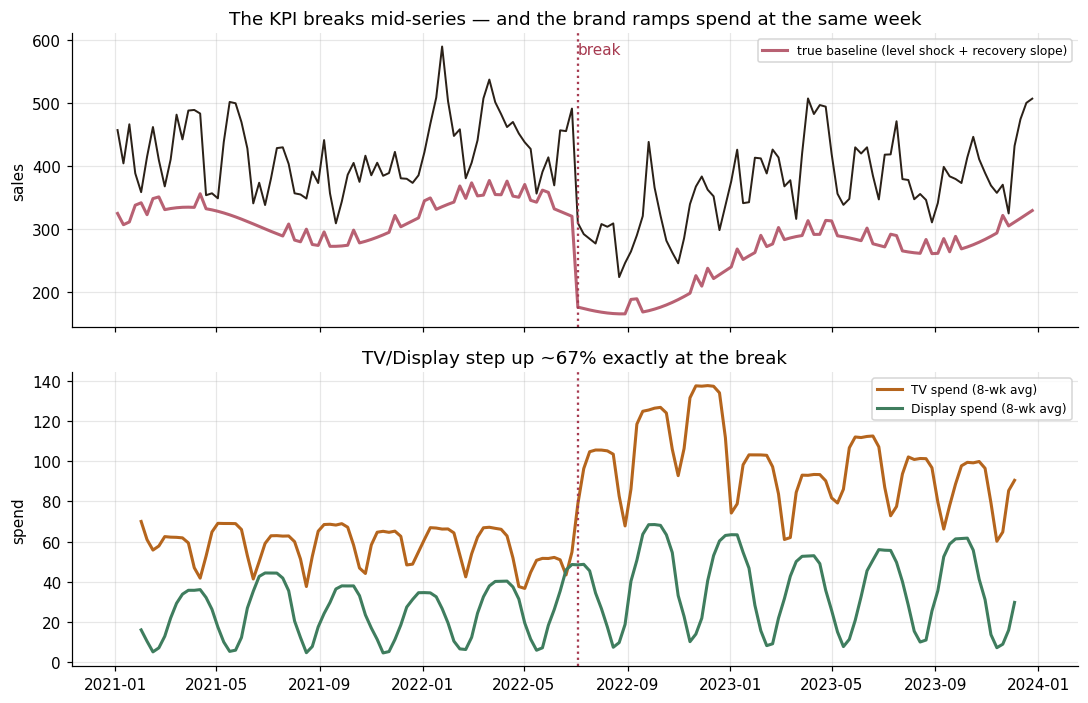

In [3]:
sc1 = dgp.build("trend_break")
n = len(sc1.y); t = np.arange(n)
brk = sc1.notes["break_week"]
print("notes:", {k: v for k, v in sc1.notes.items()})

# --- validate the new scenario before trusting it -----------------------
pwt1 = per_week_truth(sc1)                       # per-week true media KPI
assert np.allclose(pwt1.sum(), sc1.true_contribution), "truth reconstruction"
_, _, _, _, base1, _, _ = dgp._base_world(11)    # the scenario's seed is 11
shock = np.where(t >= brk, -140.0 + 1.45 * (t - brk), 0.0)
resid_dgp = sc1.y.to_numpy() - (base1 + shock + pwt1.sum(axis=1).to_numpy())
assert 15 < resid_dgp.std() < 30 and abs(resid_dgp.mean()) < 6, "leftover = noise"
print(f"DGP validated: truth reproduced exactly; residual sd "
      f"{resid_dgp.std():.1f} ~ designed noise sd 22")

ramp_tv = sc1.spend['TV'][brk:].mean() / sc1.spend['TV'][:brk].mean()
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True)
ax1.plot(sc1.weeks, sc1.y, color=INK, lw=1.3)
ax1.plot(sc1.weeks, base1 + shock, color=BERRY, lw=2, alpha=0.8,
         label="true baseline (level shock + recovery slope)")
ax1.axvline(sc1.weeks[brk], color=BERRY, ls=":", lw=1.5)
ax1.annotate("break", (sc1.weeks[brk], sc1.y.max() * 0.98), color=BERRY)
ax1.set_ylabel("sales"); ax1.legend(fontsize=8)
ax1.set_title("The KPI breaks mid-series — and the brand ramps spend at the same week")
for c in ("TV", "Display"):
    ax2.plot(sc1.weeks, sc1.spend[c].rolling(8, center=True).mean(),
             color=PAL[c], lw=2, label=f"{c} spend (8-wk avg)")
ax2.axvline(sc1.weeks[brk], color=BERRY, ls=":", lw=1.5)
ax2.set_ylabel("spend"); ax2.legend(fontsize=8)
ax2.set_title(f"TV/Display step up ~{ramp_tv - 1:.0%} exactly at the break")
plt.tight_layout(); plt.show()

## 1.1 — Naive fit: linear trend

The pre-specified default: linear trend, order-2 Fourier, Price control,
constant positive betas. Grade every channel against the counterfactual truth
(same estimand, same scale — see `tests/synth/dgp.py`).

  0%|          | 0/600 [00:00<?, ?it/s]

  0%|          | 0/600 [00:00<?, ?it/s]

Output()

Output()

Output()

Output()

Output()

[A1 naive linear]  11s   r-hat=1.015   divergences=0   med|err|=29%


,true,est,err,lo,hi,covered
channel,,,,,,
TV,5468.0,2217.0,-59.5%,840.0,3768.0,False
Search,4931.0,4899.0,-0.6%,3430.0,6657.0,True
Social,4154.0,3530.0,-15.0%,2267.0,5083.0,True
Display,2128.0,1223.0,-42.5%,261.0,2287.0,True


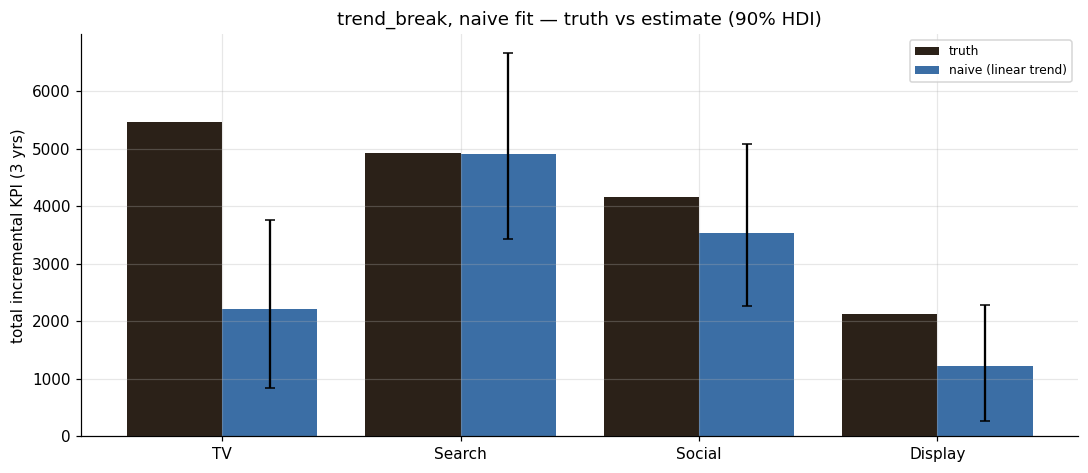

In [4]:
fit_grade("A1 naive linear", sc1)
truth_vs_est(["A1 naive linear"], ["naive (linear trend)"],
             "trend_break, naive fit — truth vs estimate (90% HDI)")

In [5]:
tabA1 = G["A1 naive linear"]["tab"]
# The headline mis-credit: the RAMPED channels get crushed.
assert float(tabA1.loc["TV", "err"]) < -0.45, "TV should be badly under-credited"
assert not bool(tabA1.loc["TV", "covered"]), "TV truth should sit outside its 90% CI"
assert G["A1 naive linear"]["med"] > 0.20
assert abs(float(tabA1.loc["Search", "err"])) < 0.15, "non-ramped Search is fine"
print(f"TV err {tabA1.loc['TV','err']:+.0%} (truth outside the 90% CI), "
      f"Display err {tabA1.loc['Display','err']:+.0%}, "
      f"Search err {tabA1.loc['Search','err']:+.0%}")

# Where did the break go? NOT into the trend: a straight line CANNOT carry it.
dec1 = G["A1 naive linear"]["mmm"].compute_component_decomposition()
true_ts = 60.0 * (t / n) + shock     # the true trend + shock (demeaned below)
Xl = np.column_stack([np.ones(n), t])
best_line = Xl @ np.linalg.lstsq(Xl, true_ts, rcond=None)[0]
print(f"peak-to-trough: true trend+shock {np.ptp(true_ts):.0f} KPI units;  "
      f"best POSSIBLE straight line through it {np.ptp(best_line):.0f};  "
      f"fitted linear trend {np.ptp(dec1.trend):.0f}")
assert np.ptp(best_line) < 0.30 * np.ptp(true_ts), "no line can carry the shock"
assert np.ptp(dec1.trend) < 0.35 * np.ptp(true_ts)

TV err -59% (truth outside the 90% CI), Display err -43%, Search err -1%
peak-to-trough: true trend+shock 141 KPI units;  best POSSIBLE straight line through it 38;  fitted linear trend 24


**What happened — and why the sign surprised us.** The scenario was *designed*
expecting the post-break recovery to be mis-credited **to** the ramped
channels. The measured failure is the mirror image: the level shock dominates
the post-break window (the baseline stays below its pre-break path for the
whole second half), so the model sees *60% more TV/Display buying visibly
fewer sales* — and concludes the ramped channels barely work. TV loses well
over half its true contribution and its truth falls **outside** the 90%
interval; Display is similarly crushed; the two non-ramped channels are
recovered fine. Same disease either way: **spend moved in lockstep with
unmodeled baseline structure, and the structure was billed to media.** Which
direction the bill goes just depends on whether the crash or the recovery
dominates the fit window — had the brand *cut* spend in the crisis (or had we
truncated the series at the break), the bias would flip to over-credit.

Note the linear trend itself absorbed little of it — and that is a
*representability* failure, not a prior failure: even the best possible
straight line through the true trend-plus-shock captures barely a quarter of
its swing (measured above), and the fitted trend lands in that same ballpark.
(When this notebook was first authored the story was worse: the then-default
growth prior, `growth_prior_sigma=0.1`, pinned the trend near zero so even
the *representable* slope went unused. That finding got the default raised to
0.5 — on the series' clean world the fitted linear trend now recovers nearly
the full true trend instead of under half of it.) Either way, a line cannot
drop 140 units in a week, so the shock had to go somewhere else.

**Which diagnostics fired?** Convergence is green (r-hat ≈ 1.02, zero
divergences) and stays green in every fit in this notebook. But the
*time-resolved residuals* scream:

Output()

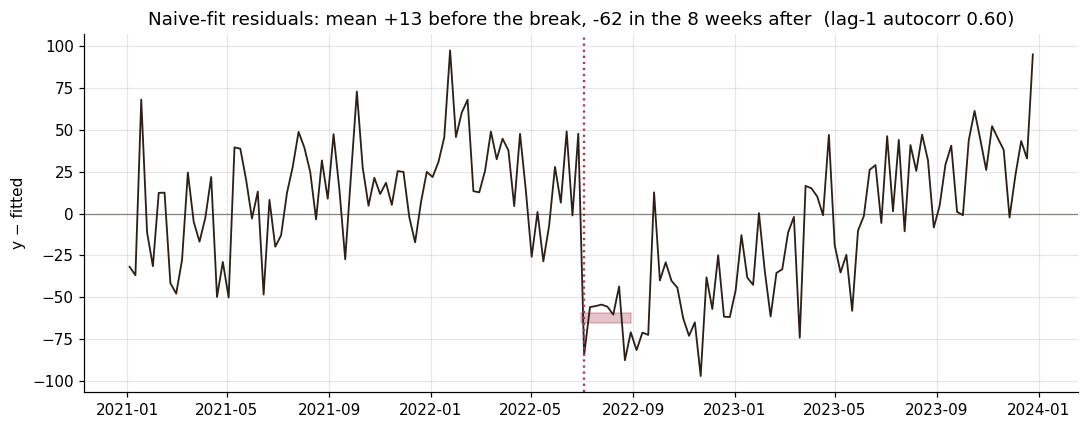

Convergence said nothing. The residual TIME PLOT is the alarm: a 75-unit cliff at a known calendar date.


In [6]:
with quiet():
    pred1 = G["A1 naive linear"]["mmm"].predict(return_original_scale=True,
                                                random_seed=0)
res1 = sc1.y.to_numpy() - pred1.y_pred_mean
pre, post8 = res1[:brk].mean(), res1[brk:brk + 8].mean()
ac1 = float(np.corrcoef(res1[:-1], res1[1:])[0, 1])
assert pre - post8 > 40, "residuals must crater right after the break"
fig, ax = plt.subplots()
ax.axhline(0, color=MUTED, lw=0.8)
ax.plot(sc1.weeks, res1, color=INK, lw=1.2)
ax.axvline(sc1.weeks[brk], color=BERRY, ls=":", lw=1.5)
ax.axhspan(post8 - 3, post8 + 3, xmin=0.5, xmax=0.55, color=BERRY, alpha=0.3)
ax.set_title(f"Naive-fit residuals: mean {pre:+.0f} before the break, "
             f"{post8:+.0f} in the 8 weeks after  (lag-1 autocorr {ac1:.2f})")
ax.set_ylabel("y − fitted"); plt.tight_layout(); plt.show()
print("Convergence said nothing. The residual TIME PLOT is the alarm:",
      f"a {pre - post8:.0f}-unit cliff at a known calendar date.")

## 1.2 — Pivot A: a trend that can bend

`TrendType.PIECEWISE` is the Prophet-style slope-change trend whose
slope-vs-level bug was fixed on 2026-06-02 (`math_03` has the algebra). Two
configurations, bracketing a framework default **that this stress test got
changed**:

* the **old default prior** (`changepoint_prior_scale=0.05`, passed explicitly
  here) — a Laplace prior on slope changes calibrated for gentle drift. When
  this notebook was first authored it *was* the default, and it failed this
  scenario; that finding drove the default up to 0.5;
* the **current default** (a bare `TrendConfig(type=TrendType.PIECEWISE)`,
  i.e. `changepoint_prior_scale=0.5`, `n_changepoints=10`) — enough freedom
  to fake a cliff as two violent slope changes.

A continuous piecewise-linear function can never *jump*, so it approximates the
level shock by diving steeply between two adjacent changepoints. The question
is whether the prior lets it dive — and out of the box, it now does.

In [7]:
fit_grade("A2 piecewise old prior", sc1,
          trend=TrendConfig(type=TrendType.PIECEWISE,
                            changepoint_prior_scale=0.05))  # pre-fix default
fit_grade("A3 piecewise default", sc1,
          trend=TrendConfig(type=TrendType.PIECEWISE))      # current defaults

  0%|          | 0/600 [00:00<?, ?it/s]

  0%|          | 0/600 [00:00<?, ?it/s]

Output()

Output()

Output()

...

Output()

Output()

[A3 piecewise default]  9s   r-hat=1.025   divergences=0   med|err|=12%


,true,est,err,lo,hi,covered
channel,,,,,,
TV,5468.0,3870.0,-29.2%,2398.0,5637.0,True
Search,4931.0,5077.0,3.0%,3961.0,6308.0,True
Social,4154.0,3615.0,-13.0%,2630.0,4829.0,True
Display,2128.0,1888.0,-11.3%,1103.0,2846.0,True


{'mmm': <mmm_framework.model.base.BayesianMMM at 0x126dfe870>,
 'res': MMMResults(trace=<xarray.DataTree>
 Group: /
 ├── Group: /posterior
 │       Dimensions:                      (chain: 2, draw: 300, changepoint: 10,
 │                                         yearly_fourier: 4, beta_controls_dim_0: 1,
 │                                         obs: 156, trend_component_dim_0: 156,
 │                                         seasonality_component_dim_0: 156,
 │                                         seasonality_by_period_dim_0: 156, channel: 4,
 │                                         media_total_dim_0: 156, control: 1)
 │       Coordinates:
 │         * chain                        (chain) int64 16B 0 1
 │         * draw                         (draw) int64 2kB 0 1 2 3 4 ... 296 297 298 299
 │         * changepoint                  (changepoint) int64 80B 0 1 2 3 4 5 6 7 8 9
 │         * yearly_fourier               (yearly_fourier) <U8 128B 'yearly_0' ... 'ye...
 │         * beta

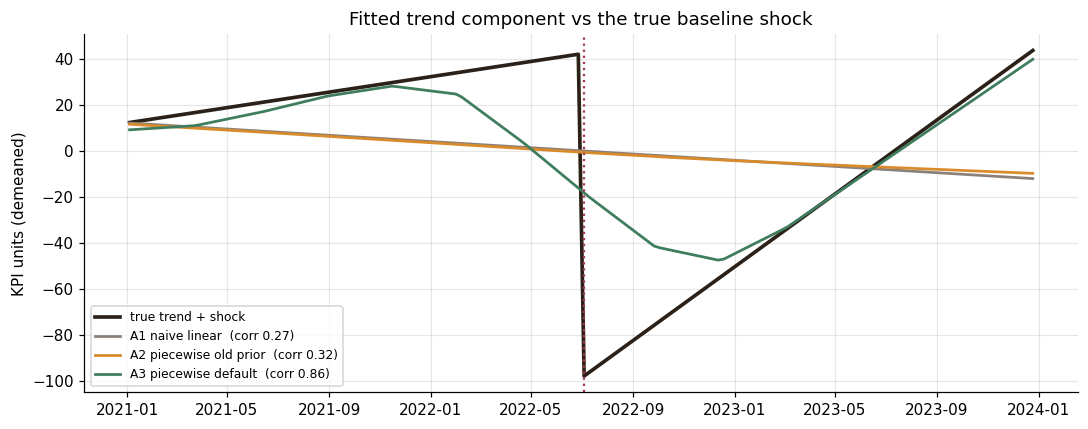

med|err|: naive 29% -> piecewise(old 0.05 prior) 26% -> piecewise(current default) 12%;  TV err -59% -> -29%


In [8]:
# How much of the true trend+shock does each fitted trend reproduce?
fig, ax = plt.subplots()
ax.plot(sc1.weeks, true_ts - true_ts.mean(), color=INK, lw=2.4,
        label="true trend + shock")
corrs = {}
for lbl, col in [("A1 naive linear", MUTED), ("A2 piecewise old prior", AMBER),
                 ("A3 piecewise default", LEAF)]:
    tr = G[lbl]["mmm"].compute_component_decomposition().trend
    corrs[lbl] = float(np.corrcoef(tr, true_ts)[0, 1])
    ax.plot(sc1.weeks, tr - tr.mean(), color=col, lw=1.8,
            label=f"{lbl}  (corr {corrs[lbl]:.2f})")
ax.axvline(sc1.weeks[brk], color=BERRY, ls=":", lw=1.5)
ax.set_title("Fitted trend component vs the true baseline shock")
ax.set_ylabel("KPI units (demeaned)"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

assert corrs["A3 piecewise default"] > 0.7, "default piecewise must track the break"
assert corrs["A2 piecewise old prior"] < 0.7, "the old 0.05 prior was too stiff"
assert G["A2 piecewise old prior"]["med"] > G["A3 piecewise default"]["med"]
assert G["A3 piecewise default"]["med"] < 0.20
a1_tv = float(G["A1 naive linear"]["tab"].loc["TV", "err"])
a3_tv = float(G["A3 piecewise default"]["tab"].loc["TV", "err"])
assert a3_tv > a1_tv + 0.20, "default piecewise must claw back TV's credit"
print(f"med|err|: naive {G['A1 naive linear']['med']:.0%} -> "
      f"piecewise(old 0.05 prior) {G['A2 piecewise old prior']['med']:.0%} -> "
      f"piecewise(current default) {G['A3 piecewise default']['med']:.0%};  "
      f"TV err {a1_tv:+.0%} -> {a3_tv:+.0%}")

**Measured:** at the **old default** changepoint prior (0.05) the piecewise
trend is no better than the line — its fitted trend barely correlates with the
truth and the channel errors are essentially unchanged. A Laplace(0, 0.05)
prior on slope changes simply refuses to pay for a 140-unit cliff. At the
**current default** (0.5) the trend visibly tracks the shock-and-recovery and
the median channel error drops far below the naive fit's, with TV recovering a
large part of its credit. A flexible trend *family* is not enough — the
*prior* on its flexibility is part of the spec. When first run, this notebook
measured exactly that gap at the then-default 0.05, and the framework default
was raised to 0.5 as a result: **the failure documented here is why the
out-of-the-box piecewise trend now handles a crash, not just drift.** The
changepoint prior remains a sensitivity knob worth auditing whenever the trend
story carries the analysis.

## 1.3 — Pivot B: name the event

If you can date the break (you usually can — it was a *crisis*), the more
surgical fix is to hand the model the event as a **control column**, not to
buy a more flexible trend. The clean path with these scenarios: assign onto
`Scenario.controls` *before* calling `.panel()` (the panel builds its configs
from the control columns). Two versions:

* **step dummy** `1[t ≥ break]` — represents the level shift only;
* **step + ramp** `(t − break)₊` — represents the level shift *and* the new
  recovery slope, i.e. everything we know about the shock's shape.

In [9]:
sc1_step = dgp.build("trend_break")
sc1_step.controls = sc1_step.controls.assign(PostBreak=(t >= brk).astype(float))
fit_grade("A4 step dummy", sc1_step)
print("controls in the model:", G["A4 step dummy"]["mmm"].control_names)
assert "PostBreak" in G["A4 step dummy"]["mmm"].control_names

sc1_ramp = dgp.build("trend_break")
sc1_ramp.controls = sc1_ramp.controls.assign(
    PostBreak=(t >= brk).astype(float),
    Recovery=np.maximum(t - brk, 0).astype(float))
fit_grade("A5 step + ramp", sc1_ramp)

  0%|          | 0/600 [00:00<?, ?it/s]

  0%|          | 0/600 [00:00<?, ?it/s]

Output()

Output()

Output()

...

Output()

Output()

[A5 step + ramp]  10s   r-hat=1.021   divergences=0   med|err|=12%


,true,est,err,lo,hi,covered
channel,,,,,,
TV,5468.0,3953.0,-27.7%,2726.0,5497.0,True
Search,4931.0,4776.0,-3.1%,3924.0,5740.0,True
Social,4154.0,3618.0,-12.9%,2712.0,4704.0,True
Display,2128.0,2367.0,11.3%,1464.0,3416.0,True


{'mmm': <mmm_framework.model.base.BayesianMMM at 0x12c9e02f0>,
 'res': MMMResults(trace=<xarray.DataTree>
 Group: /
 ├── Group: /posterior
 │       Dimensions:                      (chain: 2, draw: 300, yearly_fourier: 4,
 │                                         beta_controls_dim_0: 3, obs: 156,
 │                                         trend_component_dim_0: 156,
 │                                         seasonality_component_dim_0: 156,
 │                                         seasonality_by_period_dim_0: 156, channel: 4,
 │                                         media_total_dim_0: 156, control: 3)
 │       Coordinates:
 │         * chain                        (chain) int64 16B 0 1
 │         * draw                         (draw) int64 2kB 0 1 2 3 4 ... 296 297 298 299
 │         * yearly_fourier               (yearly_fourier) <U8 128B 'yearly_0' ... 'ye...
 │         * beta_controls_dim_0          (beta_controls_dim_0) int64 24B 0 1 2
 │         * obs                        

In [10]:
# Cheap sensitivity row: the B-spline trend (no event knowledge needed).
fit_grade("A6 spline trend", sc1,
          trend=TrendConfig(type=TrendType.SPLINE, n_knots=12))

  0%|          | 0/600 [00:00<?, ?it/s]

  0%|          | 0/600 [00:00<?, ?it/s]

Output()

Output()

Output()

Output()

Output()

[A6 spline trend]  13s   r-hat=1.018   divergences=0   med|err|=11%


,true,est,err,lo,hi,covered
channel,,,,,,
TV,5468.0,4393.0,-19.7%,2889.0,6141.0,True
Search,4931.0,4931.0,0.0%,4004.0,5934.0,True
Social,4154.0,3503.0,-15.7%,2625.0,4487.0,True
Display,2128.0,1990.0,-6.5%,1191.0,2865.0,True


{'mmm': <mmm_framework.model.base.BayesianMMM at 0x127628230>,
 'res': MMMResults(trace=<xarray.DataTree>
 Group: /
 ├── Group: /posterior
 │       Dimensions:                      (chain: 2, draw: 300, spline_idx: 16,
 │                                         yearly_fourier: 4, beta_controls_dim_0: 1,
 │                                         obs: 156, trend_component_dim_0: 156,
 │                                         seasonality_component_dim_0: 156,
 │                                         seasonality_by_period_dim_0: 156, channel: 4,
 │                                         media_total_dim_0: 156, control: 1)
 │       Coordinates:
 │         * chain                        (chain) int64 16B 0 1
 │         * draw                         (draw) int64 2kB 0 1 2 3 4 ... 296 297 298 299
 │         * spline_idx                   (spline_idx) int64 128B 0 1 2 3 ... 12 13 14 15
 │         * yearly_fourier               (yearly_fourier) <U8 128B 'yearly_0' ... 'ye...
 │         * b

,med |err|,TV err,Display err,TV covered
A1 naive linear,+29%,-59%,-43%,False
A2 piecewise old prior,+26%,-55%,-40%,False
A3 piecewise default,+12%,-29%,-11%,True
A4 step dummy,+15%,-32%,-15%,False
A5 step + ramp,+12%,-28%,+11%,True
A6 spline trend,+11%,-20%,-6%,True


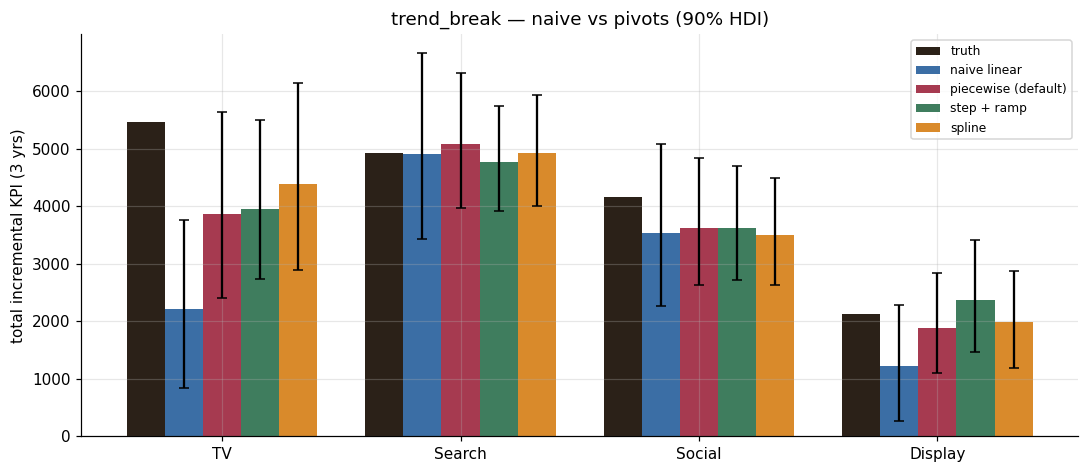

best remaining TV error across all pivots: -20%


In [11]:
order = ["A1 naive linear", "A2 piecewise old prior", "A3 piecewise default",
         "A4 step dummy", "A5 step + ramp", "A6 spline trend"]
summary1 = pd.DataFrame({
    "med |err|": {k: G[k]["med"] for k in order},
    "TV err": {k: float(G[k]["tab"].loc["TV", "err"]) for k in order},
    "Display err": {k: float(G[k]["tab"].loc["Display", "err"]) for k in order},
    "TV covered": {k: bool(G[k]["tab"].loc["TV", "covered"]) for k in order},
}).map(lambda v: f"{v:+.0%}" if isinstance(v, float) else v)
display(summary1)
truth_vs_est(["A1 naive linear", "A3 piecewise default", "A5 step + ramp",
              "A6 spline trend"],
             ["naive linear", "piecewise (default)", "step + ramp", "spline"],
             "trend_break — naive vs pivots (90% HDI)")
assert all(G[k]["med"] < 0.20 for k in
           ["A3 piecewise default", "A5 step + ramp", "A6 spline trend"])
# Honest residual: TV stays meaningfully under-credited in EVERY pivot.
worst_tv = max(float(G[k]["tab"].loc["TV", "err"]) for k in
               ["A3 piecewise default", "A4 step dummy", "A5 step + ramp",
                "A6 spline trend"])
assert worst_tv < -0.10, "no pivot fully recovers TV"
print("best remaining TV error across all pivots:", f"{worst_tv:+.0%}")

**Reading the table.** The step dummy alone helps but underperforms the
trend pivots — it buys the level shift back, but the *recovery slope* it can't
represent keeps leaking. Encoding the full event shape (step **and** ramp)
matches the best trend-based fix; the spline (which needed no event knowledge,
only flexibility) lands in the same place. And one honest residual: **TV stays
under-credited by roughly a fifth to a third in every pivot.** The flexible
trends widen its 90% interval enough to cover the truth; the more surgical
event controls, being tighter, can still leave it just outside (see the
`TV covered` column). That is the identification limit, not a spec bug — the brand changed TV at exactly the week the world changed, so the data
cannot fully split "ramped TV" from "recovering baseline". The flexible trend
returns the *representable* part of the credit and honestly widens the
interval over the rest.

> **Takeaway.** A structural break the brand responded to is a *confounder
> manufactured by your own media plan*. A linear trend bills the shock to the
> ramped channels with green convergence. Pivots that work, in order of
> preference: (1) date the event and add step + ramp controls; (2) a piecewise
> or spline trend with a prior loose enough to actually bend — the current
> default (`changepoint_prior_scale=0.5`) **is**; the old 0.05 default was
> not, and this scenario is why it changed. And expect a residual haircut on
> any channel that moved at the break: only an experiment fully separates it.

---
# Act 2 — Seasonality the Fourier basis cannot say

**The world.** Three departures from the model's order-2 yearly Fourier, all
common in retail: the seasonal **amplitude grows ~60%** across the three years
(the brand scales); there are **sharp holiday spikes** — weeks 47–48 (Black
Friday/Cyber) and 50–51 (Christmas), +160 KPI each, far too sharp for any
low-order Fourier; and **Social's flighting is seasonal** — its budget runs
3× in Q4, sitting directly on the spikes. The designed danger: unmodeled
holiday lift is available to be credited to the channel that spends on
holidays. Validate the new scenario first, then look at the world.

DGP validated (residual sd 21.4 ~ 22). Social spends 48% of its budget in Q4 (12 weeks/year).


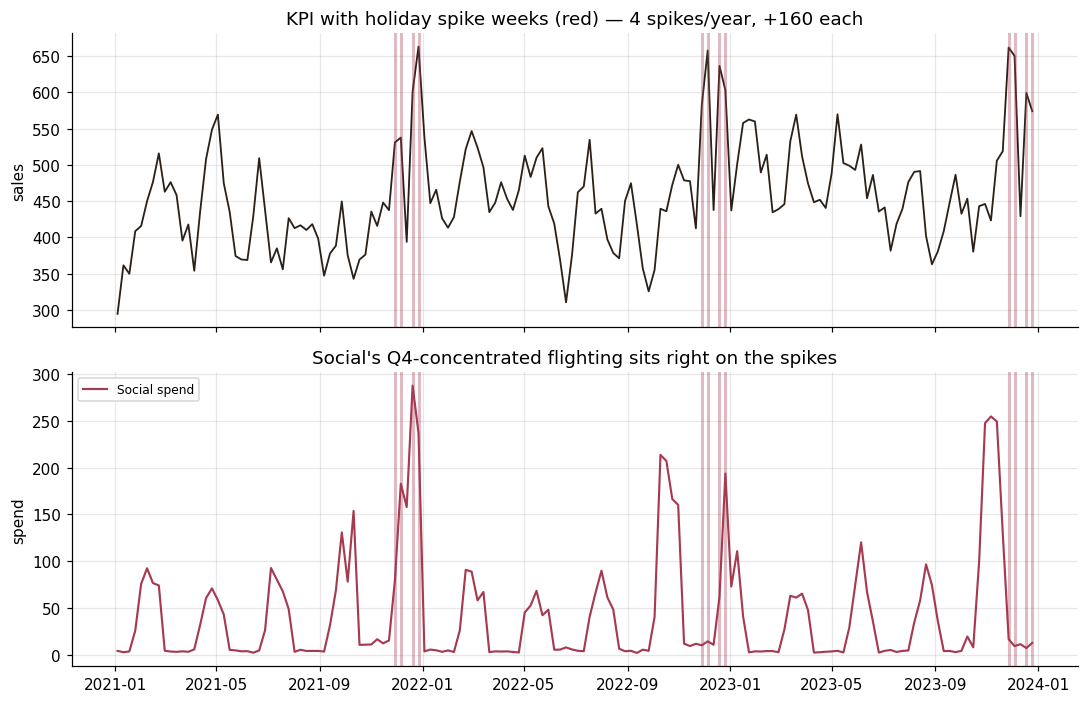

In [12]:
sc2 = dgp.build("seasonality_misspec")
hol = np.asarray(sc2.notes["holiday_indicator"], float)
q4 = np.asarray(sc2.notes["q4_indicator"], float)

# --- validate the new scenario ------------------------------------------
pwt2 = per_week_truth(sc2)
assert np.allclose(pwt2.sum(), sc2.true_contribution), "truth reconstruction"
_, _, _, _, base2, _, _ = dgp._base_world(12)        # scenario seed is 12
static = 35.0 * np.sin(2 * np.pi * t / 52.0) + 22.0 * np.cos(2 * np.pi * t / 52.0)
season_true = (1.0 + 0.6 * t / n) * static + 160.0 * hol
resid_dgp2 = sc2.y.to_numpy() - (base2 - static + season_true
                                 + pwt2.sum(axis=1).to_numpy())
assert 15 < resid_dgp2.std() < 30 and abs(resid_dgp2.mean()) < 6
q4_share = sc2.spend["Social"][q4 == 1].sum() / sc2.spend["Social"].sum()
print(f"DGP validated (residual sd {resid_dgp2.std():.1f} ~ 22). "
      f"Social spends {q4_share:.0%} of its budget in Q4 (12 weeks/year).")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True)
ax1.plot(sc2.weeks, sc2.y, color=INK, lw=1.2)
for w in np.where(hol == 1)[0]:
    ax1.axvline(sc2.weeks[w], color=BERRY, alpha=0.35, lw=2)
ax1.set_ylabel("sales")
ax1.set_title("KPI with holiday spike weeks (red) — 4 spikes/year, +160 each")
ax2.plot(sc2.weeks, sc2.spend["Social"], color=PAL["Social"], lw=1.4,
         label="Social spend")
for w in np.where(hol == 1)[0]:
    ax2.axvline(sc2.weeks[w], color=BERRY, alpha=0.35, lw=2)
ax2.set_ylabel("spend"); ax2.legend(fontsize=8)
ax2.set_title("Social's Q4-concentrated flighting sits right on the spikes")
plt.tight_layout(); plt.show()

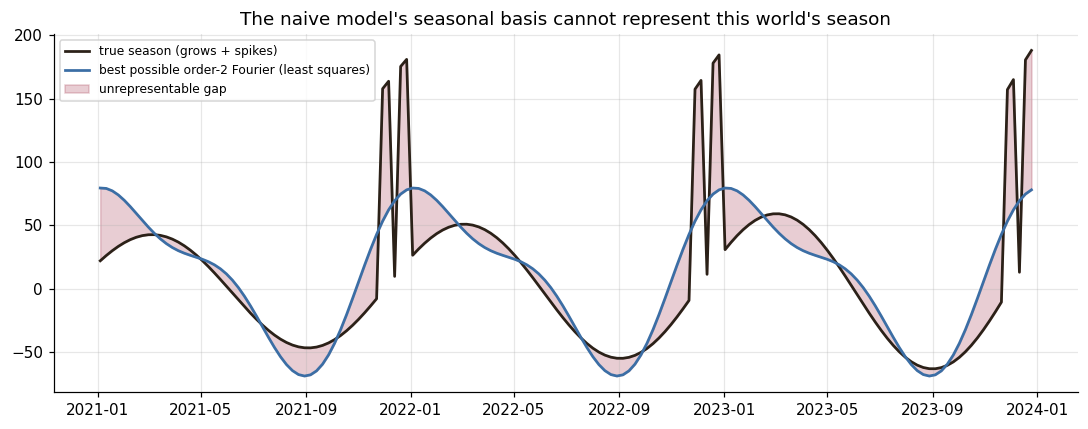

unrepresentable seasonal KPI (|gap| summed): 3,683 -- vs total true media contribution 17,924


In [13]:
# What can the model's order-2 Fourier even SAY about this season?
X2 = np.column_stack([np.ones(n)] +
                     [f(2 * np.pi * k * t / 52.0) for k in (1, 2)
                      for f in (np.sin, np.cos)])
approx2 = X2 @ np.linalg.lstsq(X2, season_true, rcond=None)[0]
gap = season_true - approx2
fig, ax = plt.subplots()
ax.plot(sc2.weeks, season_true, color=INK, lw=1.8, label="true season (grows + spikes)")
ax.plot(sc2.weeks, approx2, color=SKY, lw=1.8,
        label="best possible order-2 Fourier (least squares)")
ax.fill_between(sc2.weeks, approx2, season_true, color=BERRY, alpha=0.25,
                label="unrepresentable gap")
ax.set_title("The naive model's seasonal basis cannot represent this world's season")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
print(f"unrepresentable seasonal KPI (|gap| summed): {np.abs(gap).sum():,.0f} "
      f"-- vs total true media contribution {sc2.true_contribution.sum():,.0f}")

That shaded gap — the holiday spikes plus the amplitude growth that no
order-2 Fourier can produce — is baseline KPI with nowhere to live. It sums to
a meaningful fraction of all media contribution. Fit the naive model and see
who gets billed.

  0%|          | 0/600 [00:00<?, ?it/s]

  0%|          | 0/600 [00:00<?, ?it/s]

Output()

Output()

Output()

Output()

Output()

[B1 naive fourier-2]  10s   r-hat=1.014   divergences=0   med|err|=14%


,true,est,err,lo,hi,covered
channel,,,,,,
TV,7751.0,8171.0,5.4%,4632.0,12495.0,True
Search,4990.0,4556.0,-8.7%,2867.0,7106.0,True
Social,2819.0,2276.0,-19.2%,1206.0,3642.0,True
Display,2364.0,812.0,-65.6%,48.0,2839.0,True


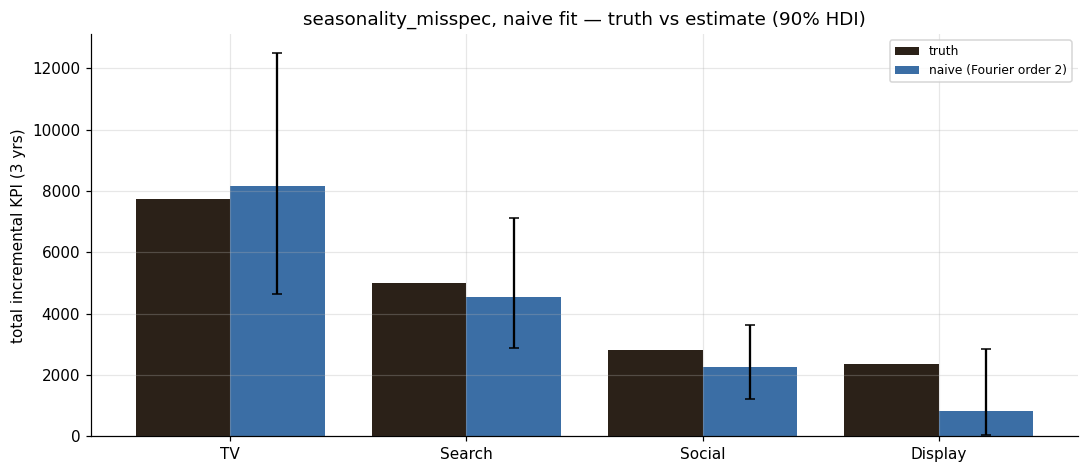

In [14]:
fit_grade("B1 naive fourier-2", sc2)
truth_vs_est(["B1 naive fourier-2"], ["naive (Fourier order 2)"],
             "seasonality_misspec, naive fit — truth vs estimate (90% HDI)")

In [15]:
tabB1 = G["B1 naive fourier-2"]["tab"]
tot_err = float(tabB1["est"].sum() / tabB1["true"].sum() - 1)
assert abs(tot_err) < 0.15, "TOTAL media looks fine..."
assert float(tabB1.loc["Display", "err"]) < -0.45, "...but Display is crushed"
assert tabB1["err"].abs().max() > 0.45, "...someone pays badly for the misfit"
assert float(tabB1.loc["Social", "err"]) < 0.05, "Social is NOT the beneficiary"
assert abs(float(tabB1.loc["TV", "err"])) < 0.30, \
    "TV is no longer the beneficiary at the current trend defaults"
assert G["B1 naive fourier-2"]["med"] > 0.10
print(f"total-media error {tot_err:+.0%} (looks healthy!)  but per channel: "
      + "  ".join(f"{c} {tabB1.loc[c,'err']:+.0%}" for c in tabB1.index))

# residual check: does the unmodeled holiday lift survive into residuals?
with quiet():
    predB1 = G["B1 naive fourier-2"]["mmm"].predict(return_original_scale=True,
                                                    random_seed=0)
resB1 = sc2.y.to_numpy() - predB1.y_pred_mean
hol_resid = resB1[hol == 1].mean() - resB1[hol == 0].mean()
assert hol_resid > 60, "holiday weeks must stick out of the residuals"
print(f"holiday-week residual excess: {hol_resid:+.0f} KPI "
      f"(true spike = +160; the other ~{160 - hol_resid:.0f} was absorbed "
      "by media/season)")

Output()

total-media error -12% (looks healthy!)  but per channel: TV +5%  Search -9%  Social -19%  Display -66%


holiday-week residual excess: +111 KPI (true spike = +160; the other ~49 was absorbed by media/season)


**Measured — and another design surprise.** The scenario was built so *Social*
would harvest the holiday lift. It doesn't. Social comes out modestly **under**
its truth, TV lands close to its own, and **Display** loses roughly
two-thirds of its contribution — all while *total* media stays within ~15% of
the truth and convergence is green. The split got scrambled, not the targeted
channel inflated.

A plausible mechanism (offered as interpretation, not measurement): Social's
own Q4 concentration sets its saturation normalizer — in spike weeks it sits
on the *flat top* of its response curve, so crediting it with a +160 spike
would require a beta that also blows up its 140 non-Q4 weeks. The posterior
instead leaves most of the spike in the residuals and rebalances the rest of
the year by squeezing whoever is most expendable — here Display, the smallest
channel. And the victim is not even stable across *specs*: when this notebook
first ran (under the framework's old, stiffer trend priors — since changed,
see Act 1) the very same world over-credited **TV** by roughly a third
instead. The lesson is sharper than the designed one: **you cannot predict
which channel pays for misspecified seasonality** — the misfit finds the
accounting-cheapest victim, the totals stay plausible, and only the
holiday-week residual excess (about two-thirds of the spike survives in the
residuals) gives the game away.

## 2.2 — Pivot A: events are *controls*, not seasonality

A holiday spike is not "seasonality" in the Fourier sense — it is a dated,
recurring **event**. The right spec move is the same as Act 1's: put the
indicator in the design matrix as a control column.

In [16]:
sc2_hol = dgp.build("seasonality_misspec")
sc2_hol.controls = sc2_hol.controls.assign(Holiday=hol)
fit_grade("B2 holiday control", sc2_hol)
assert "Holiday" in G["B2 holiday control"]["mmm"].control_names

  0%|          | 0/600 [00:00<?, ?it/s]

  0%|          | 0/600 [00:00<?, ?it/s]

Output()

Output()

Output()

Output()

Output()

[B2 holiday control]  10s   r-hat=1.017   divergences=0   med|err|=2%


,true,est,err,lo,hi,covered
channel,,,,,,
TV,7751.0,7849.0,1.3%,6100.0,9824.0,True
Search,4990.0,4937.0,-1.1%,4040.0,5929.0,True
Social,2819.0,2888.0,2.5%,1894.0,3978.0,True
Display,2364.0,1748.0,-26.1%,1245.0,2312.0,False


## 2.3 — Pivot B: just raise the Fourier order?

The tempting alternative: keep everything inside the seasonality block and
crank `SeasonalityConfig(yearly=6)`. Two reasons to expect disappointment: a
1-week spike needs harmonics near order ~26, not 6; and the amplitude *growth*
is not periodic at all, so no static Fourier order can represent it. There is
also a feared failure mode — a flexible season absorbing genuine media lift —
which we measure rather than assert.

In [17]:
fit_grade("B3 fourier-6", sc2, yearly=6)

  0%|          | 0/600 [00:00<?, ?it/s]

  0%|          | 0/600 [00:00<?, ?it/s]

Output()

Output()

Output()

Output()

Output()

[B3 fourier-6]  12s   r-hat=1.020   divergences=0   med|err|=13%


,true,est,err,lo,hi,covered
channel,,,,,,
TV,7751.0,8087.0,4.3%,5107.0,11387.0,True
Search,4990.0,5455.0,9.3%,3438.0,8258.0,True
Social,2819.0,2360.0,-16.3%,1208.0,3906.0,True
Display,2364.0,871.0,-63.1%,62.0,2211.0,False


{'mmm': <mmm_framework.model.base.BayesianMMM at 0x14935ac90>,
 'res': MMMResults(trace=<xarray.DataTree>
 Group: /
 ├── Group: /posterior
 │       Dimensions:                      (chain: 2, draw: 300, yearly_fourier: 12,
 │                                         beta_controls_dim_0: 1, obs: 156,
 │                                         trend_component_dim_0: 156,
 │                                         seasonality_component_dim_0: 156,
 │                                         seasonality_by_period_dim_0: 156, channel: 4,
 │                                         media_total_dim_0: 156, control: 1)
 │       Coordinates:
 │         * chain                        (chain) int64 16B 0 1
 │         * draw                         (draw) int64 2kB 0 1 2 3 4 ... 296 297 298 299
 │         * yearly_fourier               (yearly_fourier) <U9 432B 'yearly_0' ... 'ye...
 │         * beta_controls_dim_0          (beta_controls_dim_0) int64 8B 0
 │         * obs                          (o

,med |err|,Social err,TV err,Display err,total media err
B1 naive fourier-2,+14%,-19%,+5%,-66%,-12%
B2 holiday control,+2%,+2%,+1%,-26%,-3%
B3 fourier-6,+13%,-16%,+4%,-63%,-6%


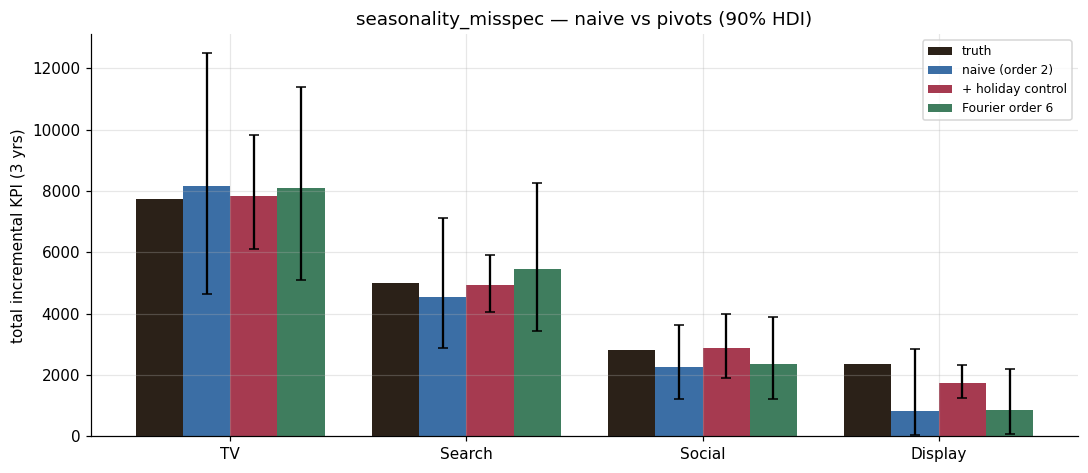

med|err|: naive 14% -> holiday control 2% -> fourier-6 13%


In [18]:
orderB = ["B1 naive fourier-2", "B2 holiday control", "B3 fourier-6"]
summary2 = pd.DataFrame({
    "med |err|": {k: G[k]["med"] for k in orderB},
    "Social err": {k: float(G[k]["tab"].loc["Social", "err"]) for k in orderB},
    "TV err": {k: float(G[k]["tab"].loc["TV", "err"]) for k in orderB},
    "Display err": {k: float(G[k]["tab"].loc["Display", "err"]) for k in orderB},
    "total media err": {k: float(G[k]["tab"]["est"].sum()
                                 / G[k]["tab"]["true"].sum() - 1) for k in orderB},
}).map(lambda v: f"{v:+.0%}" if isinstance(v, float) else v)
display(summary2)
truth_vs_est(orderB, ["naive (order 2)", "+ holiday control", "Fourier order 6"],
             "seasonality_misspec — naive vs pivots (90% HDI)")

assert G["B2 holiday control"]["med"] < 0.15
assert G["B2 holiday control"]["med"] < 0.6 * G["B1 naive fourier-2"]["med"]
assert abs(float(G["B2 holiday control"]["tab"].loc["Social", "err"])) < 0.15
assert G["B3 fourier-6"]["med"] > G["B2 holiday control"]["med"], \
    "raising the order must NOT beat the event control"
assert float(G["B3 fourier-6"]["tab"].loc["Display", "err"]) < -0.35, \
    "order-6 leaves Display badly wrong"
b1m, b2m, b3m = (G[k]["med"] for k in orderB)
print(f"med|err|: naive {b1m:.0%} -> holiday control {b2m:.0%} "
      f"-> fourier-6 {b3m:.0%}")

**Measured.** The holiday **control** is the clear winner: median error drops
to low single digits and Social lands almost exactly on its truth. Raising the
Fourier order barely dents the damage — it can sketch a Q4 hump but not
1-week spikes, and the amplitude growth stays unrepresentable, so Display in
particular remains far under truth. As for the "flexible season eats media"
fear: at order 6 it did **not** materialize on the totals here (total media
stayed within a few percent) — the risk is real in worlds with smoother media
flighting, but on this data the honest statement is that order-6 simply *fails
to fix the problem*, not that it backfired. One residual blemish even in the
winning pivot: with the spikes controlled, Display still ends about a quarter
under truth with its interval just missing — the amplitude growth is still
unmodeled and still has to land somewhere.

> **Takeaway.** Dated events belong in the design matrix as **controls**;
> Fourier terms are for smooth, repeating shape. When seasonality is
> misspecified the *total* stays plausible and the **cross-channel split**
> takes the damage — in whatever direction the saturation geometry makes
> cheapest, not necessarily toward the channel you'd suspect. The
> holiday-week residual excess is the cheap, decisive diagnostic.

---
# Act 3 — Effectiveness that drifts under a constant beta

**The world** (`time_varying_beta`): TV's effectiveness **fatigues** from
1.4× to 0.6× over the three years (creative wear-out); Search **doubles+** at
a mid-series break (0.6× → 1.5×, an algorithm/creative refresh); Social
wobbles seasonally; Display is constant. The model fits one constant beta per
channel.

The recorded stress matrix (`tests/synth/results/stress_matrix.md`,
re-recorded on current code) grades this scenario **green** — med|err| ~12%,
full coverage — under the harness's own configuration (PyMC 500×500,
parametric adstock, seeded counterfactual scoring). This notebook's fits tell
a less comfortable story: at our settings TV's 3-year total comes out
**~40% under-credited and outside its 90% interval**. A verdict that flips
between "green" and "badly wrong" with the fitting budget is itself a finding
— totals-level green under drifting effectiveness is *fragile*, not robust.
And the deeper point survives in Search, which is green on totals in both
configurations — and still gives you the wrong forward-looking answer, as
we'll measure.

First reconstruct the true effectiveness paths (mirroring the factory) and
validate against the scenario's published truth.

multiplier paths validated against sc.true_contribution


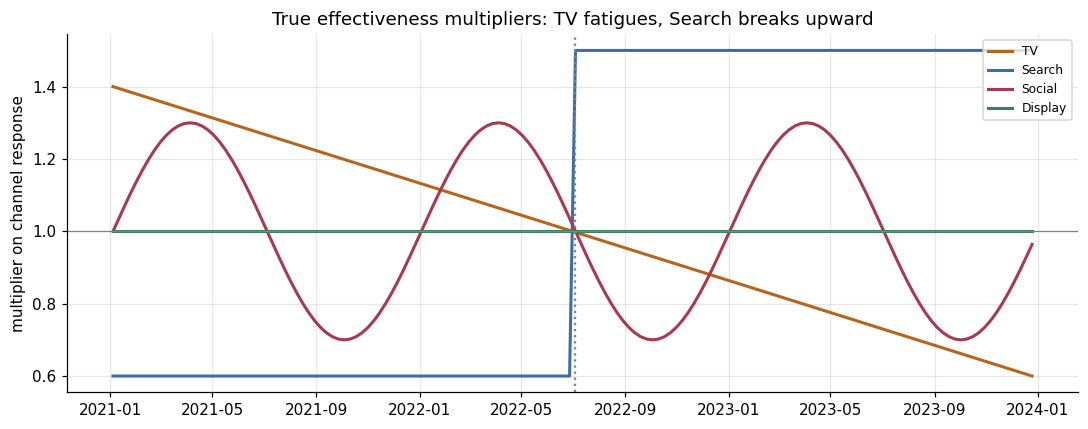

In [19]:
sc3 = dgp.build("time_varying_beta")
brk3 = sc3.notes["break_week"]
mult = {
    "TV": np.linspace(1.4, 0.6, n),
    "Search": np.where(t < brk3, 0.6, 1.5),
    "Social": 1.0 + 0.3 * np.sin(2 * np.pi * t / 52.0),
    "Display": np.ones(n),
}
pwt3 = per_week_truth(sc3, mult=mult)
assert np.allclose(pwt3.sum(), sc3.true_contribution), \
    "multiplier reconstruction must reproduce the published truth exactly"
print("multiplier paths validated against sc.true_contribution")

fig, ax = plt.subplots()
for c in ("TV", "Search", "Social", "Display"):
    ax.plot(sc3.weeks, mult[c], color=PAL[c], lw=2, label=c)
ax.axvline(sc3.weeks[brk3], color=MUTED, ls=":", lw=1.5)
ax.axhline(1.0, color=MUTED, lw=0.8)
ax.set_title("True effectiveness multipliers: TV fatigues, Search breaks upward")
ax.set_ylabel("multiplier on channel response"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

  0%|          | 0/600 [00:00<?, ?it/s]

  0%|          | 0/600 [00:00<?, ?it/s]

Output()

Output()

Output()

Output()

Output()

[C1 full fit]  10s   r-hat=1.033   divergences=0   med|err|=15%


,true,est,err,lo,hi,covered
channel,,,,,,
TV,6505.0,4037.0,-37.9%,2516.0,5817.0,False
Search,5564.0,5027.0,-9.6%,3982.0,6190.0,True
Social,4166.0,4398.0,5.6%,3294.0,5626.0,True
Display,3056.0,2404.0,-21.3%,1483.0,3550.0,True


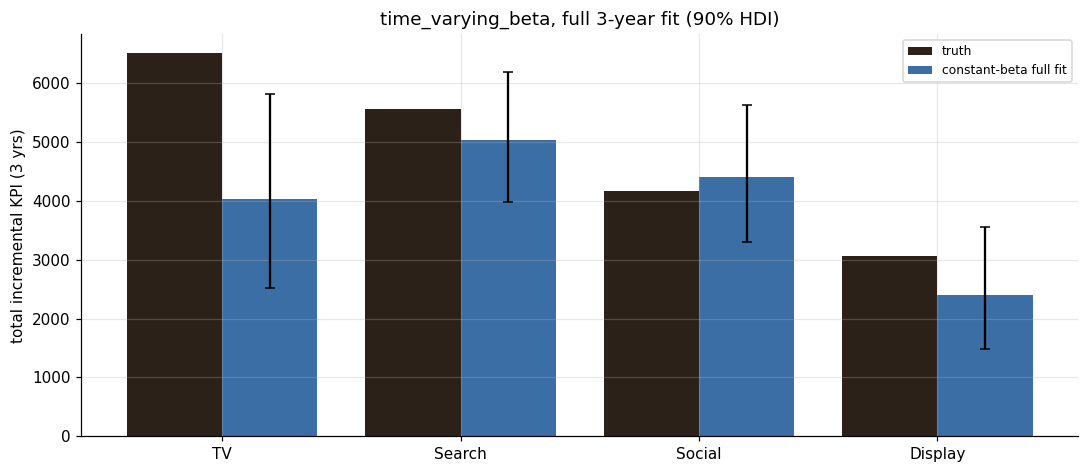

TV total err -38% (NOT covered at this budget — the config-fragile verdict);  Search total err -10% (covered, 'green')


In [20]:
fit_grade("C1 full fit", sc3)
truth_vs_est(["C1 full fit"], ["constant-beta full fit"],
             "time_varying_beta, full 3-year fit (90% HDI)")
tabC1 = G["C1 full fit"]["tab"]
assert float(tabC1.loc["TV", "err"]) < -0.30 and not bool(tabC1.loc["TV", "covered"])
assert abs(float(tabC1.loc["Search", "err"])) < 0.25 and bool(tabC1.loc["Search", "covered"])
print(f"TV total err {tabC1.loc['TV','err']:+.0%} (NOT covered at this budget — "
      f"the config-fragile verdict);  Search total err "
      f"{tabC1.loc['Search','err']:+.0%} (covered, 'green')")

**Why fatigue breaks even the total.** Intuition says a constant beta should
land on the *time-average* effectiveness and get 3-year totals right. It
doesn't for TV: a smoothly declining response is partially absorbed by the
other time-shaped components (trend, the intercept's share), and the
saturation/adstock parameters re-tune toward the late, weak regime — the
posterior compromise sits well below the average. Search's *step* averages out
much more cleanly, so its total looks fine. Watch what the constant beta does
to the **timing** of the credit:

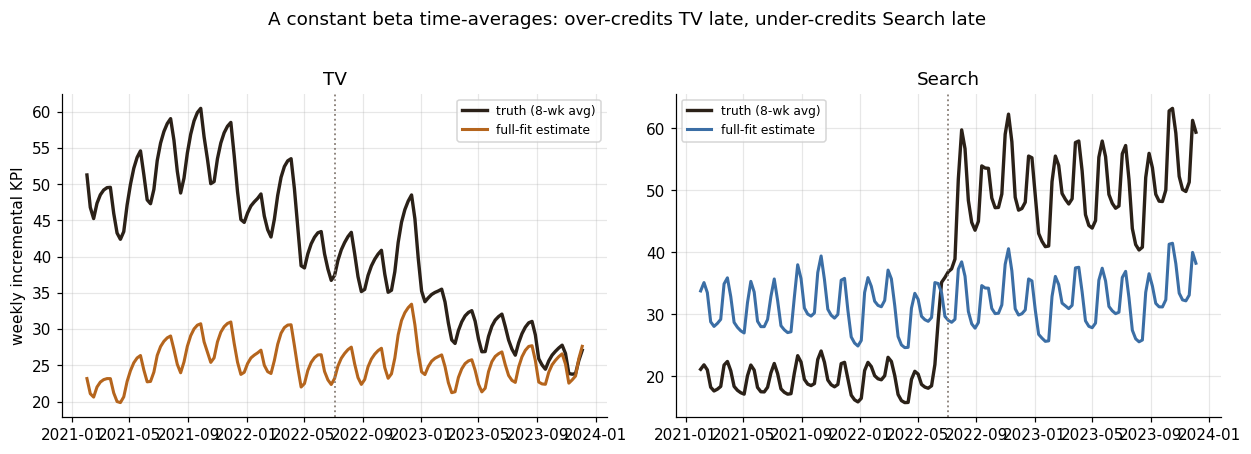

In [21]:
estC1 = G["C1 full fit"]["contrib"].channel_contributions
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4), sharey=False)
for ax, c in zip(axes, ("TV", "Search")):
    ax.plot(sc3.weeks, pwt3[c].rolling(8, center=True).mean(), color=INK, lw=2.2,
            label="truth (8-wk avg)")
    ax.plot(sc3.weeks, estC1[c].rolling(8, center=True).mean(), color=PAL[c],
            lw=2, label="full-fit estimate")
    ax.axvline(sc3.weeks[brk3], color=MUTED, ls=":", lw=1.2)
    ax.set_title(c); ax.legend(fontsize=8)
axes[0].set_ylabel("weekly incremental KPI")
fig.suptitle("A constant beta time-averages: over-credits TV late, "
             "under-credits Search late", y=1.02)
plt.tight_layout(); plt.show()

## 3.1 — The practical diagnostic: split-window refits

You will never have these truth curves. What you *can* always do: **fit the
halves separately and compare**. If the per-window betas/contributions agree
with the full fit, constancy was fine; if they diverge, the full fit is an
average over different regimes — and your *next-quarter* decision should not
be based on it. (Small caveat: the second-half window starts adstock-cold, an
edge effect of at most `l_max` = 8 weeks.)

In [22]:
def window_scenario(sc, a, b, truth_window):
    return replace(
        sc, weeks=sc.weeks[a:b],
        spend=sc.spend.iloc[a:b].reset_index(drop=True),
        y=pd.Series(sc.y.to_numpy()[a:b], index=sc.weeks[a:b], name="Sales"),
        controls=sc.controls.iloc[a:b].reset_index(drop=True),
        true_contribution=truth_window)

truth_h1, truth_h2 = pwt3.iloc[:brk3].sum(), pwt3.iloc[brk3:].sum()
assert np.allclose(truth_h1 + truth_h2, sc3.true_contribution)
fit_grade("C2 first half", window_scenario(sc3, 0, brk3, truth_h1), truth=truth_h1)
fit_grade("C3 second half", window_scenario(sc3, brk3, n, truth_h2), truth=truth_h2)

  0%|          | 0/600 [00:00<?, ?it/s]

  0%|          | 0/600 [00:00<?, ?it/s]

Output()

Output()

Output()

...

Output()

Output()

[C3 second half]  10s   r-hat=1.019   divergences=0   med|err|=23%


,true,est,err,lo,hi,covered
channel,,,,,,
TV,2606.0,1888.0,-27.6%,996.0,2928.0,True
Search,4028.0,3647.0,-9.4%,3232.0,4112.0,True
Social,1973.0,2354.0,19.3%,1719.0,3034.0,True
Display,1561.0,1099.0,-29.6%,719.0,1579.0,True


{'mmm': <mmm_framework.model.base.BayesianMMM at 0x14d786570>,
 'res': MMMResults(trace=<xarray.DataTree>
 Group: /
 ├── Group: /posterior
 │       Dimensions:                      (chain: 2, draw: 300, yearly_fourier: 4,
 │                                         beta_controls_dim_0: 1, obs: 78,
 │                                         trend_component_dim_0: 78,
 │                                         seasonality_component_dim_0: 78,
 │                                         seasonality_by_period_dim_0: 78, channel: 4,
 │                                         media_total_dim_0: 78, control: 1)
 │       Coordinates:
 │         * chain                        (chain) int64 16B 0 1
 │         * draw                         (draw) int64 2kB 0 1 2 3 4 ... 296 297 298 299
 │         * yearly_fourier               (yearly_fourier) <U8 128B 'yearly_0' ... 'ye...
 │         * beta_controls_dim_0          (beta_controls_dim_0) int64 8B 0
 │         * obs                          (obs) in

In [23]:
# The full fit, time-sliced over each half, vs the half fits, vs truth.
with quiet():
    c1_h1 = G["C1 full fit"]["mmm"].compute_counterfactual_contributions(
        time_period=(0, brk3 - 1), compute_uncertainty=False, random_seed=0)
    c1_h2 = G["C1 full fit"]["mmm"].compute_counterfactual_contributions(
        time_period=(brk3, n - 1), compute_uncertainty=False, random_seed=0)
win = pd.DataFrame({
    ("first half", "truth"): truth_h1.round(),
    ("first half", "full-fit slice"): c1_h1.total_contributions.round(),
    ("first half", "half fit"): G["C2 first half"]["tab"]["est"].round(),
    ("second half", "truth"): truth_h2.round(),
    ("second half", "full-fit slice"): c1_h2.total_contributions.round(),
    ("second half", "half fit"): G["C3 second half"]["tab"]["est"].round(),
})
display(win)
ff_tv_h1 = float(c1_h1.total_contributions["TV"] / truth_h1["TV"] - 1)
ff_se_h2 = float(c1_h2.total_contributions["Search"] / truth_h2["Search"] - 1)
hf_se_h2 = float(G["C3 second half"]["tab"].loc["Search", "err"])
assert ff_tv_h1 < -0.35, "full fit badly under-credits early TV"
assert ff_se_h2 < -0.25, "full fit badly under-credits LATE Search"
assert abs(hf_se_h2) < abs(ff_se_h2), "the half fit fixes late Search"
print(f"late-window Search: full-fit slice {ff_se_h2:+.0%} vs truth; "
      f"dedicated half fit {hf_se_h2:+.0%}.")
print(f"early-window TV: full-fit slice {ff_tv_h1:+.0%} vs truth.")

Output()

Output()

Output()

Output()

Output()

...

Output()

Output()

Output()

first half                         second half                        
             truth full-fit slice half fit       truth full-fit slice half fit
TV          3899.0         2011.0   2573.0      2606.0         2026.0   1888.0
Search      1536.0         2445.0    977.0      4028.0         2582.0   3647.0
Social      2193.0         2164.0   1871.0      1973.0         2234.0   2354.0
Display     1495.0         1177.0   1215.0      1561.0         1227.0   1099.0

late-window Search: full-fit slice -36% vs truth; dedicated half fit -9%.
early-window TV: full-fit slice -48% vs truth.


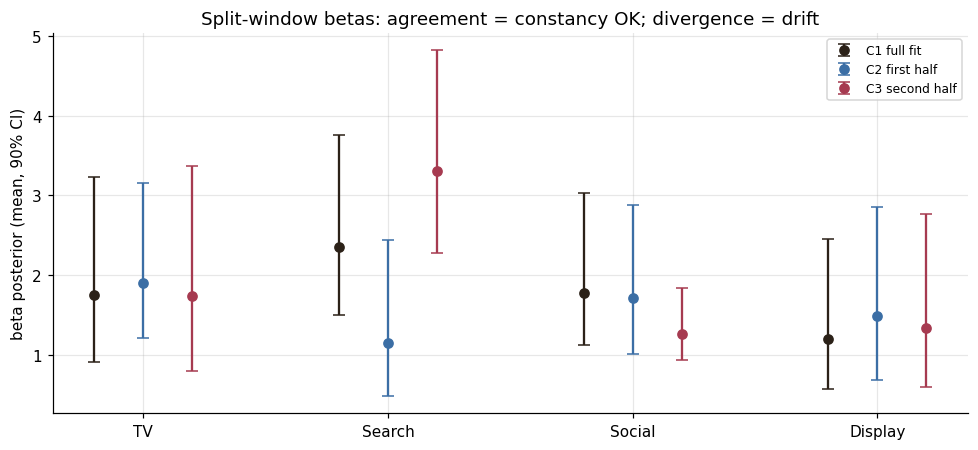

Search beta: h2/h1 = 2.9x  (true effectiveness ratio 2.5x)  -> nonstationarity flagged
Display beta: h2/h1 = 0.9x  -> constancy fine


In [24]:
# Per-window posterior betas: the split-and-compare alarm.
fig, ax = plt.subplots(figsize=(9, 4.2))
offs = {"C1 full fit": (-0.2, INK), "C2 first half": (0.0, SKY),
        "C3 second half": (0.2, BERRY)}
chans = list(sc3.channels)
for lbl, (off, colr) in offs.items():
    post = G[lbl]["res"].trace.posterior
    for i, c in enumerate(chans):
        d = post[f"beta_{c}"].values.ravel()
        m, lo, hi = d.mean(), np.quantile(d, 0.05), np.quantile(d, 0.95)
        ax.errorbar(i + off, m, yerr=[[m - lo], [hi - m]], fmt="o", ms=6,
                    color=colr, capsize=4,
                    label=lbl if i == 0 else None)
ax.set_xticks(range(len(chans))); ax.set_xticklabels(chans)
ax.set_ylabel("beta posterior (mean, 90% CI)")
ax.set_title("Split-window betas: agreement = constancy OK; divergence = drift")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

b = {lbl: {c: float(G[lbl]["res"].trace.posterior[f"beta_{c}"].mean())
           for c in chans} for lbl in offs}
ratio_search = b["C3 second half"]["Search"] / b["C2 first half"]["Search"]
ratio_display = b["C3 second half"]["Display"] / b["C2 first half"]["Display"]
assert ratio_search > 1.7, "Search's halves must disagree loudly"
assert 0.5 < ratio_display < 1.6, "Display's halves should roughly agree"
print(f"Search beta: h2/h1 = {ratio_search:.1f}x  (true effectiveness ratio "
      f"{1.5 / 0.6:.1f}x)  -> nonstationarity flagged")
print(f"Display beta: h2/h1 = {ratio_display:.1f}x  -> constancy fine")

**Measured.** The full fit's *second-half* Search credit is far below the
truth (the constant beta is dragged down by the weak first half), while the
dedicated second-half fit lands close. Search's split-window betas disagree by
roughly the true effectiveness jump; Display's halves agree, correctly
clearing the constant channel. That disagreement is computable on **any real
dataset** — no truth needed — and it is precisely the forward-looking error: a
budget for next quarter set from the full fit prices Search at a fraction of
its *current* effectiveness and TV above its current, fatigued one.

> **Takeaway.** A 3-year total can be "green" while the number you actually
> act on — *effectiveness now, at the margin* — is wrong by 2× or more.
> Split-window refits are cheap (each half fits in seconds at this size) and
> are simultaneously the **diagnostic** (betas diverge ⇒ drift) and the
> **pivot** (use the recent window's beta for forward decisions). And treat a
> harness verdict ("this scenario is green") as a property of its fitting
> budget, not of the world — this scenario flips from green (harness fidelity)
> to a missed TV truth (this notebook's budget) with nothing changed but the
> sampler settings.

---
# Closing — when does baseline structure leak into media?

One sentence: **whenever a channel's spend is correlated with time-structure
the model cannot represent.** That makes the pre-fit EDA check trivially
cheap: correlate each channel's spend with the calendar/level features you
suspect — a post-event dummy, quarter indicators, raw time.

In [25]:
post = (t >= brk).astype(float)
woy = t % 52
q4f = ((woy >= 40) & (woy <= 51)).astype(float)
eda = pd.DataFrame({
    "trend_break: corr(spend, post-break)": {
        c: np.corrcoef(sc1.spend[c], post)[0, 1] for c in sc1.channels},
    "seasonality: corr(spend, Q4)": {
        c: np.corrcoef(sc2.spend[c], q4f)[0, 1] for c in sc2.channels},
    "time_varying: corr(spend, t)": {
        c: np.corrcoef(sc3.spend[c], t)[0, 1] for c in sc3.channels},
}).round(2)
display(eda)
assert eda.loc["TV", "trend_break: corr(spend, post-break)"] > 0.10
assert eda.loc["Social", "seasonality: corr(spend, Q4)"] > 0.30
assert eda["time_varying: corr(spend, t)"].abs().max() < 0.15
print("Acts 1-2 are visible BEFORE fitting (TV/Display load on the break, "
      "Social on Q4).")
print("Act 3 is invisible in spend — the drift is in the response. "
      "Only split-window refits catch it.")

,"trend_break: corr(spend, post-break)","seasonality: corr(spend, Q4)","time_varying: corr(spend, t)"
TV,0.22,-0.02,-0.00
Search,-0.02,-0.07,0.03
Social,-0.02,0.44,-0.04
Display,0.17,0.04,-0.02


Acts 1-2 are visible BEFORE fitting (TV/Display load on the break, Social on Q4).
Act 3 is invisible in spend — the drift is in the response. Only split-window refits catch it.


In [26]:
budget = pd.Series(TIMINGS, name="seconds")
display(budget.to_frame())
print(f"Total sampling wall-clock: {budget.sum():.0f}s across {len(budget)} fits "
      f"({DRAWS} draws x {CHAINS} chains, numpyro).")

,seconds
A1 naive linear,11.2
A2 piecewise old prior,11.5
A3 piecewise default,9.1
A4 step dummy,12.3
A5 step + ramp,10.5
A6 spline trend,13.3
B1 naive fourier-2,9.8
B2 holiday control,10.2
B3 fourier-6,12.3
C1 full fit,10.3


Total sampling wall-clock: 135s across 12 fits (300 draws x 2 chains, numpyro).


## What to remember

| symptom | likely cause | pivot |
|---|---|---|
| residual cliff at a calendar date; ramped channel crushed (or inflated) with green r-hat | structural break + brand reacted with spend | step **+ ramp** event controls; piecewise/spline trend (the changepoint prior must be loose enough to bend — the current 0.5 default is; the old 0.05 was not); expect a residual haircut on the channel that moved at the break |
| totals fine, channel split absurd; holiday/promo weeks stick out of residuals | seasonality outside the Fourier family (spikes, growing amplitude) | event **controls** for dated spikes — raising the Fourier order is a half-fix at best |
| full-fit numbers fine, but split-window betas disagree | time-varying effectiveness (fatigue, step changes) | split-and-compare *is* the diagnostic; use the recent window for forward decisions |

1. **The model will spend your unmodeled structure somewhere.** With
   correlated spend it lands on media; the sign depends on the geometry, not
   on your intuition (both acts 1 and 2 surprised their own designer).
2. **Convergence stayed green in all twelve fits.** Time-resolved residuals
   fired in all three acts — plot residuals against the *calendar*, not just
   their histogram.
3. **Flexibility has a prior.** The piecewise trend exists for exactly this —
   and when this notebook was first written it *failed* at its then-default
   changepoint scale (0.05). That measured failure got the framework default
   raised to 0.5 (likewise the linear growth prior, 0.1 → 0.5), and the same
   fit now passes out of the box. The prior on flexibility is still part of
   the spec: audit it whenever the trend story carries the analysis.
4. **Cheap, dated knowledge beats flexible machinery.** A two-column event
   control (step + ramp) matched the best trend family in Act 1 and won Act 2
   outright.

**Next:** [stress_03_confounding_and_selection.ipynb](stress_03_confounding_and_selection.ipynb)
— the failure modes that *no* residual plot catches: confounding, noisy
proxies, collinearity, and the variable-selection traps of dense control sets.